<a href="https://colab.research.google.com/github/sydas13/ML_Lab_Codes/blob/main/Question13.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [62]:
from google.colab import files

In [63]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

In [64]:
uploaded = files.upload()

Saving customer_data.csv to customer_data (4).csv


In [65]:

df = pd.read_csv('customer_data.csv')

X = df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']]

In [66]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

In [67]:
wcss = []
k_values = range(1, 11)
for i in k_values:
    # K-Means uses Euclidean distance (L2 norm) by default
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X_scaled_df)
    wcss.append(kmeans.inertia_)

In [68]:
plt.figure(figsize=(10, 6))
plt.plot(k_values, wcss, marker='o', linestyle='--')
plt.title('Elbow Method for Optimal K (Euclidean Distance)')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS (Within-Cluster Sum of Squares)')
plt.grid(True)
plt.savefig('kmeans_elbow_plot.png')
plt.close()

In [69]:
K = 5
kmeans = KMeans(n_clusters=K, init='k-means++', random_state=42, n_init=10)
df['Euclidean_Cluster'] = kmeans.fit_predict(X_scaled_df)

centroids = scaler.inverse_transform(kmeans.cluster_centers_)
centroids_df = pd.DataFrame(centroids, columns=X.columns)

print(f"K-Means Clustering performed with K={K} (Euclidean Distance).")
print("\nCluster Centroids (Original Scale):\n")
print(centroids_df)

K-Means Clustering performed with K=5 (Euclidean Distance).

Cluster Centroids (Original Scale):

         Age  Annual Income (k$)  Spending Score (1-100)
0  46.250000           26.750000               18.350000
1  25.185185           41.092593               62.240741
2  32.875000           86.100000               81.525000
3  39.871795           86.102564               19.358974
4  55.638298           54.382979               48.851064


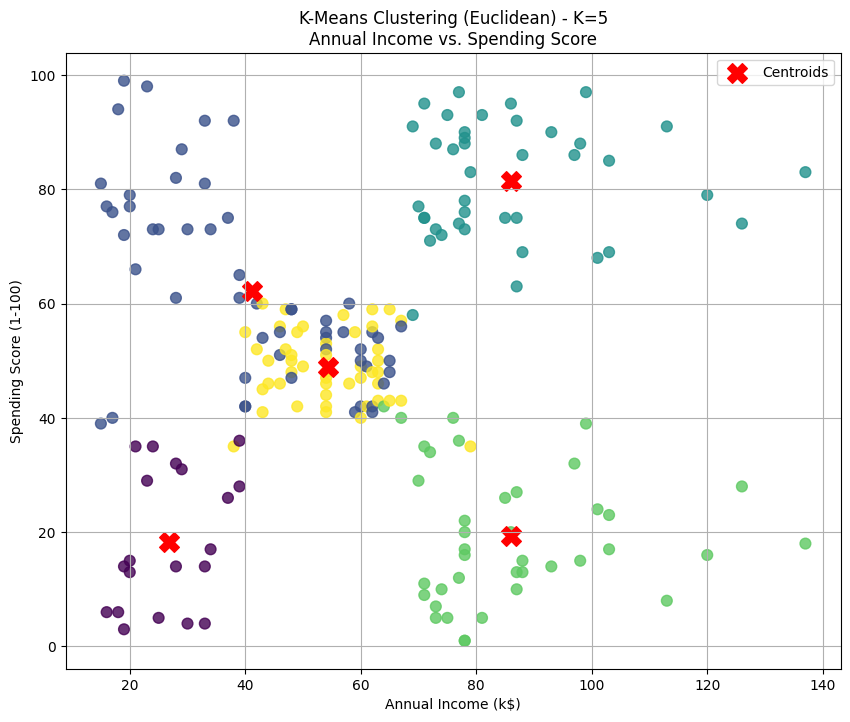

In [70]:
plt.figure(figsize=(10, 8))
plt.scatter(df['Annual Income (k$)'], df['Spending Score (1-100)'],
            c=df['Euclidean_Cluster'], cmap='viridis', s=60, alpha=0.8)
plt.scatter(centroids_df['Annual Income (k$)'], centroids_df['Spending Score (1-100)'],
            marker='X', s=200, color='red', label='Centroids')
plt.title(f'K-Means Clustering (Euclidean) - K={K}\nAnnual Income vs. Spending Score')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend()
plt.grid(True)
plt.savefig('kmeans_2d_plot.png')


In [71]:
plt.close()

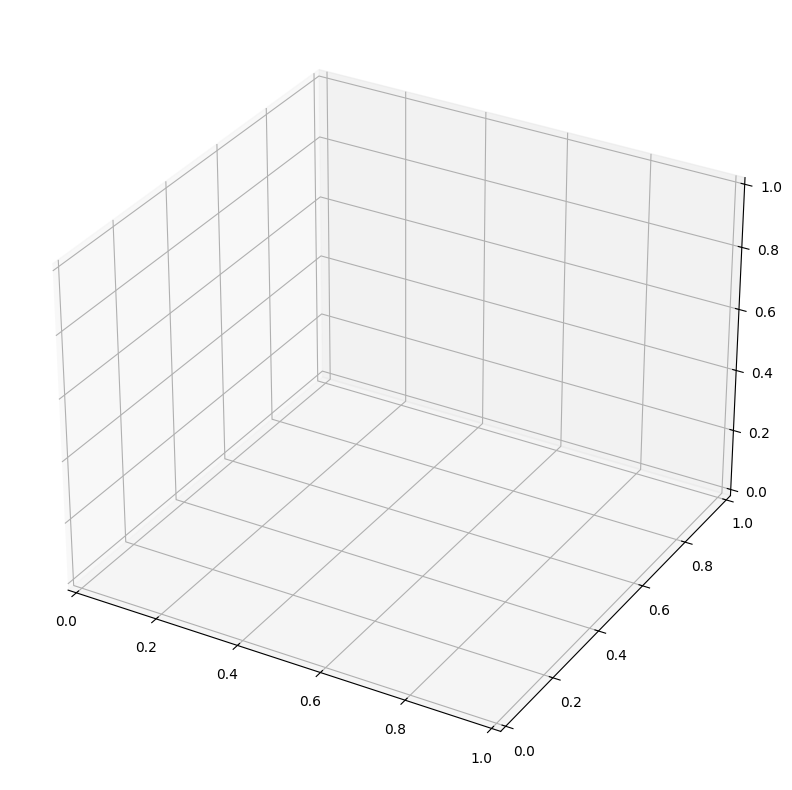

In [72]:
fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

In [73]:
scatter = ax.scatter(df['Age'], df['Annual Income (k$)'], df['Spending Score (1-100)'],
                     c=df['Euclidean_Cluster'], cmap='viridis', s=60, alpha=0.7)

In [74]:
ax.scatter(centroids_df['Age'], centroids_df['Annual Income (k$)'], centroids_df['Spending Score (1-100)'],
           marker='X', s=300, color='red', label='Centroids', alpha=1.0)

ax.set_title(f'K-Means Clustering (Euclidean) - K={K}\n3D View of Customer Segments')
ax.set_xlabel('Age')
ax.set_ylabel('Annual Income (k$)')
ax.set_zlabel('Spending Score (1-100)')

Text(0.09332506951644345, 0.012503188505254604, 'Spending Score (1-100)')

In [77]:
cbar = fig.colorbar(scatter, ax=ax, pad=0.1)
cbar.set_label('Cluster Label')
plt.show()
plt.savefig('kmeans_3d_plot.png')

<Figure size 640x480 with 0 Axes>

In [76]:
plt.close()